```markdown
# EDA Consolidado: Análisis de Negocio Integral

Este informe presenta el análisis exploratorio de datos de las hojas de **Inventario**, **Ventas** y **Compras** del archivo `Negocio_clase.xlsx`.
```

```markdown
## Paso 0 · Carga y Limpieza Estructural
Cargamos las tres hojas principales y eliminamos el ruido de celdas vacías típico de los archivos Excel.
```

## Paso 0 · Cargar los datos
Cargamos el archivo Excel disponible en el entorno.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo Excel
file_path = '/content/Negocio_clase.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Producto,ID_Producto,Categoria,ID_Categoria,Costo,Unidades,Precio,Ventas,Unidades restantes
0,Camiseta de Portugal de Ronaldo,CAT-01-01,Camisetas,CAT-01,100000,1,200000,1,0
1,Camiseta de Argentina de Messi,CAT-01-02,Camisetas,CAT-01,100000,1,200000,1,0
2,Camiseta de Colombia de James,CAT-01-03,Camisetas,CAT-01,100000,1,200000,1,0
3,Camiseta de Noruega de Haaland,CAT-01-04,Camisetas,CAT-01,100000,1,200000,1,0
4,Camiseta de Millonarios de Falcao,CAT-01-05,Camisetas,CAT-01,100000,1,200000,1,0


In [2]:
import pandas as pd
from google.colab import files
import os

# Verificar si el archivo existe, si no, pedir subirlo
file_path = '/content/Negocio_clase.xlsx'
if not os.path.exists(file_path):
    print("Archivo no encontrado. Por favor, sube 'Negocio_clase.xlsx':")
    subido = files.upload()
    # Asegurarse de que el nombre coincida o usar el subido
    if list(subido.keys()):
        file_path = list(subido.keys())[0]

# Cargar el archivo Excel completo para ver las hojas
xl = pd.ExcelFile(file_path)
print(f"Hojas encontradas: {xl.sheet_names}")

# Resumen de cada hoja
hojas_dict = {}
for name in xl.sheet_names:
    hojas_dict[name] = pd.read_excel(file_path, sheet_name=name)
    print(f"\n--- Resumen de la hoja: {name} ---")
    print(f"Forma: {hojas_dict[name].shape}")
    display(hojas_dict[name].head(2))

Archivo no encontrado. Por favor, sube 'Negocio_clase.xlsx':


Saving Negocio_clase.xlsx to Negocio_clase.xlsx
Hojas encontradas: ['Inventario', 'Ventas', 'Compras', 'Clientes', 'Empleados']

--- Resumen de la hoja: Inventario ---
Forma: (11, 9)


,Producto,ID_Producto,Categoria,ID_Categoria,Costo,Unidades,Precio,Ventas,Unidades restantes
0,Camiseta de Portugal de Ronaldo,CAT-01-01,Camisetas,CAT-01,100000,1,200000,1,0
1,Camiseta de Argentina de Messi,CAT-01-02,Camisetas,CAT-01,100000,1,200000,1,0



--- Resumen de la hoja: Ventas ---
Forma: (83, 34)


,ID_Venta,Ronda,Descuento,Comprador,ID_Cliente,Nombre del Producto,ID_Venta Producto,Categoria,Unidades vendidas,Valor del producto,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,VEN_001,1.0,0.0,Sara,CLI-02,Camiseta de Noruega de Haaland,VEN_001-CAT-01-04,Camisetas,1.0,200000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VEN_002,1.0,0.0,Alison,CLI-03,Bowl Vegetariano,VEN_002-CAT-02-02,Almuerzos,2.0,18000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,Compras,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,ID_Venta,Comprador,ID_Empleado,Producto,Unidades_Compradas,Precio,Descuento,Valor,Ahorro por descuento
1,COM_001,Antoine,EMP-002,Limon,1,2000,0,2000,0



--- Resumen de la hoja: Clientes ---
Forma: (5, 2)


,Nombre_del_cliente,ID_Cliente
0,Jorge,CLI-01
1,Sara,CLI-02



--- Resumen de la hoja: Empleados ---
Forma: (4, 2)


,Nombre_del_empleado,ID_Empleado
0,David,EMP-001
1,Antoine,EMP-002


## Análisis Detallado de todas las Hojas
❯ Automatización del entendimiento inicial y calidad para cada pestaña del Excel.


ANÁLISIS DE LA HOJA: Inventario

1. Dimensiones: 11 filas, 9 columnas
2. Calidad: 0 valores nulos, 0 filas duplicadas

3. Resumen estadístico:


,Producto,ID_Producto,Categoria,ID_Categoria,Costo,Unidades,Precio,Ventas,Unidades restantes
count,11,11,11,11,11.000000,11.000000,11.000000,11.00000,11.00000
unique,11,11,3,3,NaN,NaN,NaN,NaN,NaN
top,Camiseta de Portugal de Ronaldo,CAT-01-01,Camisetas,CAT-01,NaN,NaN,NaN,NaN,NaN
freq,1,1,5,5,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,48981.818182,4.000000,97963.636364,3.00000,1.00000
std,NaN,NaN,NaN,NaN,48893.083727,3.098387,97786.167455,2.32379,1.67332
min,NaN,NaN,NaN,NaN,1800.000000,1.000000,3600.000000,1.00000,0.00000
25%,NaN,NaN,NaN,NaN,7250.000000,1.000000,14500.000000,1.00000,0.00000
50%,NaN,NaN,NaN,NaN,9000.000000,5.000000,18000.000000,3.00000,0.00000
75%,NaN,NaN,NaN,NaN,100000.000000,6.500000,200000.000000,4.50000,1.50000


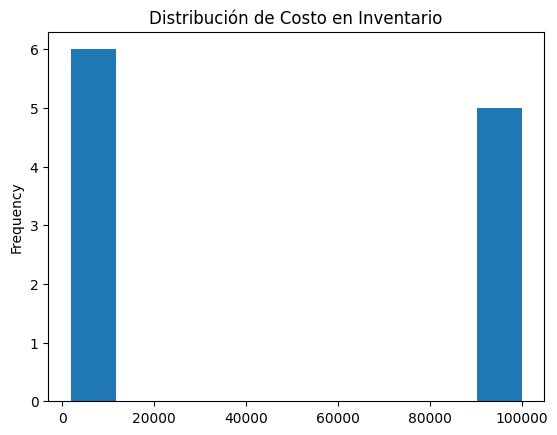


ANÁLISIS DE LA HOJA: Ventas

1. Dimensiones: 83 filas, 34 columnas
2. Calidad: 2629 valores nulos, 65 filas duplicadas

3. Resumen estadístico:


,ID_Venta,Ronda,Descuento,Comprador,ID_Cliente,Nombre del Producto,ID_Venta Producto,Categoria,Unidades vendidas,Valor del producto,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
count,16,16.000000,16.00000,16,16,16,16,16,16.00000,16.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
unique,16,NaN,NaN,5,5,11,16,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,VEN_001,NaN,NaN,Juan Felipe,CLI-05,Bowl Vegetariano,VEN_001-CAT-01-04,Almuerzos,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,x
freq,1,NaN,NaN,5,5,3,1,7,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,2.375000,0.46875,NaN,NaN,NaN,NaN,NaN,2.06250,72412.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.806226,0.28918,NaN,NaN,NaN,NaN,NaN,1.12361,88944.491117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,0.00000,NaN,NaN,NaN,NaN,NaN,1.00000,3600.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.000000,0.30000,NaN,NaN,NaN,NaN,NaN,1.00000,16250.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.000000,0.70000,NaN,NaN,NaN,NaN,NaN,2.00000,18000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.000000,0.70000,NaN,NaN,NaN,NaN,NaN,3.00000,200000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


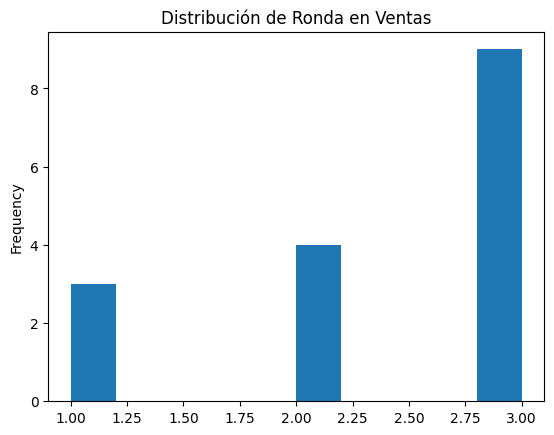


ANÁLISIS DE LA HOJA: Compras

1. Dimensiones: 11 filas, 9 columnas
2. Calidad: 0 valores nulos, 0 filas duplicadas

3. Resumen estadístico:


,Compras,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
count,11,11,11,11,11,11,11.0,11,11
unique,11,4,4,10,5,8,5.0,10,9
top,ID_Venta,Antoine,EMP-002,Labiales,1,8000,0.3,5600,0
freq,1,4,4,2,4,2,4.0,2,2



ANÁLISIS DE LA HOJA: Clientes

1. Dimensiones: 5 filas, 2 columnas
2. Calidad: 0 valores nulos, 0 filas duplicadas

3. Resumen estadístico:


,Nombre_del_cliente,ID_Cliente
count,5,5
unique,5,5
top,Jorge,CLI-01
freq,1,1



ANÁLISIS DE LA HOJA: Empleados

1. Dimensiones: 4 filas, 2 columnas
2. Calidad: 0 valores nulos, 0 filas duplicadas

3. Resumen estadístico:


,Nombre_del_empleado,ID_Empleado
count,4,4
unique,4,4
top,David,EMP-001
freq,1,1


In [4]:
import matplotlib.pyplot as plt

for name, df_sheet in hojas_dict.items():
    print(f"\n{'='*40}")
    print(f"ANÁLISIS DE LA HOJA: {name}")
    print(f"{'='*40}")

    # Entendimiento
    print(f"\n1. Dimensiones: {df_sheet.shape[0]} filas, {df_sheet.shape[1]} columnas")

    # Calidad
    nulos = df_sheet.isnull().sum().sum()
    duplicados = df_sheet.duplicated().sum()
    print(f"2. Calidad: {nulos} valores nulos, {duplicados} filas duplicadas")

    # Estadísticas
    print("\n3. Resumen estadístico:")
    display(df_sheet.describe(include='all'))

    # Visualización rápida si hay datos numéricos
    num_vars = df_sheet.select_dtypes(include=['number']).columns
    if not num_vars.empty:
        df_sheet[num_vars[0]].plot(kind='hist', title=f'Distribución de {num_vars[0]} en {name}')
        plt.show()

## Paso Final &#183; Limpieza Autom&#225;tica
❯ Eliminaci&#243;n de columnas y filas totalmente vac&#237;as que suelen aparecer al importar desde Excel.

In [5]:
for name in hojas_dict:
    # Eliminar columnas que sean todas nulas
    hojas_dict[name] = hojas_dict[name].dropna(axis=1, how='all')
    # Eliminar filas que sean todas nulas
    hojas_dict[name] = hojas_dict[name].dropna(axis=0, how='all')
    print(f"Hoja '{name}' limpia. Nueva forma: {hojas_dict[name].shape}")

# Ejemplo de visualizaci&#243;n de la hoja Ventas ya limpia
display(hojas_dict['Ventas'].head())

Hoja 'Inventario' limpia. Nueva forma: (11, 9)
Hoja 'Ventas' limpia. Nueva forma: (17, 13)
Hoja 'Compras' limpia. Nueva forma: (11, 9)
Hoja 'Clientes' limpia. Nueva forma: (5, 2)
Hoja 'Empleados' limpia. Nueva forma: (4, 2)


,ID_Venta,Ronda,Descuento,Comprador,ID_Cliente,Nombre del Producto,ID_Venta Producto,Categoria,Unidades vendidas,Valor del producto,Valor de venta,Perdida mercado,Unnamed: 33
0,VEN_001,1.0,0.0,Sara,CLI-02,Camiseta de Noruega de Haaland,VEN_001-CAT-01-04,Camisetas,1.0,200000.0,200000.0,0.0,NaN
1,VEN_002,1.0,0.0,Alison,CLI-03,Bowl Vegetariano,VEN_002-CAT-02-02,Almuerzos,2.0,18000.0,36000.0,0.0,NaN
2,VEN_003,1.0,0.0,Jorge,CLI-01,Camiseta de Colombia de James,VEN_003-CAT-01-03,Camisetas,1.0,200000.0,200000.0,0.0,NaN
3,VEN_004,2.0,0.3,Juan Esteban,CLI-04,Baguette,VEN_004-CAT-03-01,Panaderia,3.0,3600.0,7560.0,3240.0,NaN
4,VEN_005,2.0,0.3,Juan Esteban,CLI-04,Menu pollo pesto,VEN_005-CAT-02-01,Almuerzos,3.0,18000.0,37800.0,16200.0,NaN


## EDA Específico · Inventario, Ventas y Compras
Realizaremos un análisis profundo de las tres áreas clave del negocio.

### 1. Análisis de Inventario
❯ Enfoque en disponibilidad y valorización de productos.

,Costo,Unidades,Precio,Ventas,Unidades restantes
count,11.000000,11.000000,11.000000,11.00000,11.00000
mean,48981.818182,4.000000,97963.636364,3.00000,1.00000
std,48893.083727,3.098387,97786.167455,2.32379,1.67332
min,1800.000000,1.000000,3600.000000,1.00000,0.00000
25%,7250.000000,1.000000,14500.000000,1.00000,0.00000
50%,9000.000000,5.000000,18000.000000,3.00000,0.00000
75%,100000.000000,6.500000,200000.000000,4.50000,1.50000
max,100000.000000,8.000000,200000.000000,8.00000,5.00000


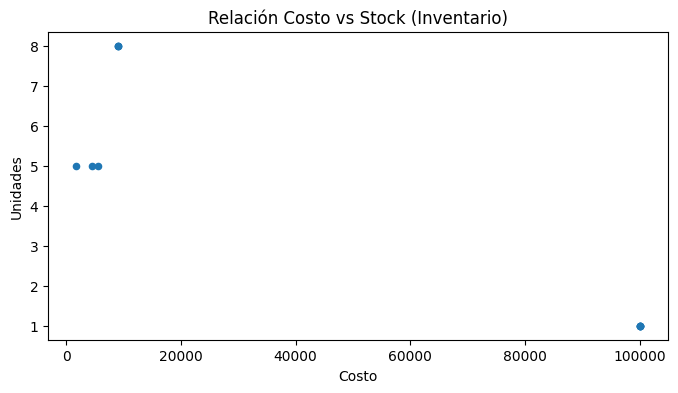

In [13]:
df_inv = hojas_dict['Inventario']
# Mostrar resumen estadístico de las columnas presentes
display(df_inv.describe())

# Ajustar visualización: Usar 'Costo' vs 'Unidades' ya que 'Precio' no existe
if 'Costo' in df_inv.columns and 'Unidades' in df_inv.columns:
    df_inv.plot.scatter(x='Costo', y='Unidades', title='Relación Costo vs Stock (Inventario)', figsize=(8, 4))
    plt.show()

### 2. Análisis de Ventas
❯ Enfoque en rendimiento comercial y descuentos.

,Valor de venta
Categoria,
Camisetas,580000.0
Almuerzos,140400.0
Panaderia,42060.0


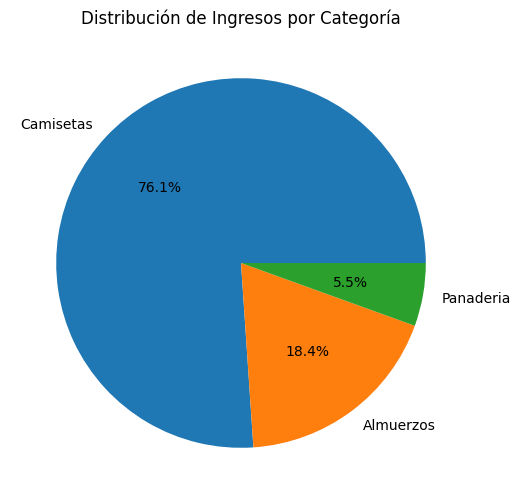

In [14]:
df_ven = hojas_dict['Ventas']
# Total de ventas por categoría usando el nuevo archivo
if 'Categoria' in df_ven.columns and 'Valor de venta' in df_ven.columns:
    ventas_cat = df_ven.groupby('Categoria')['Valor de venta'].sum().sort_values(ascending=False)
    display(ventas_cat)
    ventas_cat.plot(kind='pie', autopct='%1.1f%%', title='Distribución de Ingresos por Categoría', figsize=(6, 6))
    plt.ylabel('')
    plt.show()

### 3. Análisis de Compras
❯ Enfoque en el abastecimiento y costos de adquisición.

Resumen de Compras (Limpio):


/tmp/ipykernel_3953/92764597.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_com[col] = pd.to_numeric(df_com[col], errors='ignore')


,ID_Venta,Comprador,ID_Empleado,Producto,Unidades_Compradas,Precio,Descuento,Valor,Ahorro por descuento
0,COM_001,Antoine,EMP-002,Limon,1,2000,0.0,2000.0,0
1,COM_002,Antoine,EMP-002,Papaya,3,6000,0.0,18000.0,0
2,COM_003,Jhonatan,EMP-004,Pitaya,1,8000,0.1,7200.0,800
3,COM_004,Jhonatan,EMP-004,Bananas,9,4000,0.1,32400.0,3600
4,COM_005,David,EMP-001,Labiales,2,7500,0.3,10500.0,4500


,ID_Venta,Comprador,ID_Empleado,Producto,Unidades_Compradas,Precio,Descuento,Valor,Ahorro por descuento
count,10,10,10,10,10.000000,10.000000,10.000000,10.000000,10.00000
unique,10,3,3,9,NaN,NaN,NaN,NaN,NaN
top,COM_001,Antoine,EMP-002,Labiales,NaN,NaN,NaN,NaN,NaN
freq,1,4,4,2,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.500000,8090.000000,0.280000,10939.000000,6591.00000
std,NaN,NaN,NaN,NaN,2.415229,6048.222879,0.252982,8857.833257,10475.32174
min,NaN,NaN,NaN,NaN,1.000000,2000.000000,0.000000,2000.000000,0.00000
25%,NaN,NaN,NaN,NaN,1.000000,4500.000000,0.100000,5887.500000,1200.00000
50%,NaN,NaN,NaN,NaN,2.000000,7500.000000,0.300000,7100.000000,2700.00000
75%,NaN,NaN,NaN,NaN,2.750000,8000.000000,0.300000,13380.000000,4275.00000


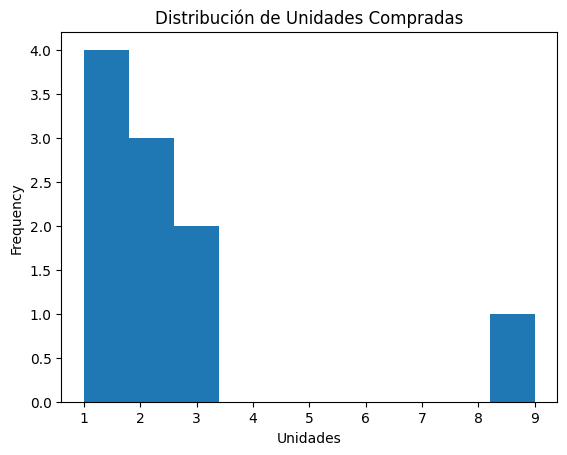

In [9]:
df_com = hojas_dict['Compras']

# Corregir encabezados si la primera fila contiene los nombres reales
if 'Unnamed' in df_com.columns[0] or 'Compras' in df_com.columns[0]:
    df_com.columns = df_com.iloc[0]
    df_com = df_com[1:].reset_index(drop=True)
    # Convertir a numérico lo que sea posible
    for col in df_com.columns:
        df_com[col] = pd.to_numeric(df_com[col], errors='ignore')

print("Resumen de Compras (Limpio):")
display(df_com.head())
display(df_com.describe(include='all'))

# Visualización de Unidades Compradas
if 'Unidades_Compradas' in df_com.columns:
    df_com['Unidades_Compradas'].plot(kind='hist', title='Distribución de Unidades Compradas')
    plt.xlabel('Unidades')
    plt.show()

## Paso 1 · Preparación y Limpieza Técnica Consolidada
Carga de datos y eliminación de ruido estructural de Excel (nulos y corrección de cabeceras).

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = '/content/Negocio_clase.xlsx'
if os.path.exists(file_path):
    xl = pd.ExcelFile(file_path)
    hojas_dict = {name: pd.read_excel(file_path, sheet_name=name) for name in xl.sheet_names}

    for name in hojas_dict:
        # Limpieza de celdas vacías estructurales
        hojas_dict[name] = hojas_dict[name].dropna(axis=1, how='all').dropna(axis=0, how='all')

        # Corrección de cabeceras para 'Compras' si es necesario
        if name == 'Compras' and any('Unnamed' in str(c) for c in hojas_dict[name].columns):
            hojas_dict[name].columns = hojas_dict[name].iloc[0]
            hojas_dict[name] = hojas_dict[name][1:].reset_index(drop=True)
            hojas_dict[name] = hojas_dict[name].apply(pd.to_numeric, errors='ignore')

    print(f"Hojas procesadas y listas: {list(hojas_dict.keys())}")

Hojas procesadas y listas: ['Inventario', 'Ventas', 'Compras', 'Clientes', 'Empleados']


/tmp/ipykernel_3953/3268074093.py:19: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  hojas_dict[name] = hojas_dict[name].apply(pd.to_numeric, errors='ignore')


## Paso 2 · Calidad de datos
❯ Revisión de valores nulos y duplicados.

In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")

# Limpieza básica: eliminar duplicados si existen
df = df.drop_duplicates()
print("\nDataset después de eliminar duplicados:", df.shape)

Valores nulos por columna:
Producto              0
ID_Producto           0
Categoria             0
ID_Categoria          0
Costo                 0
Unidades              0
Precio                0
Ventas                0
Unidades restantes    0
dtype: int64

Cantidad de filas duplicadas: 0

Dataset después de eliminar duplicados: (11, 9)


## Paso 2 · Análisis de Rentabilidad y KPIs por Área
Enfoque en la distribución de ingresos por categoría y métricas descriptivas.

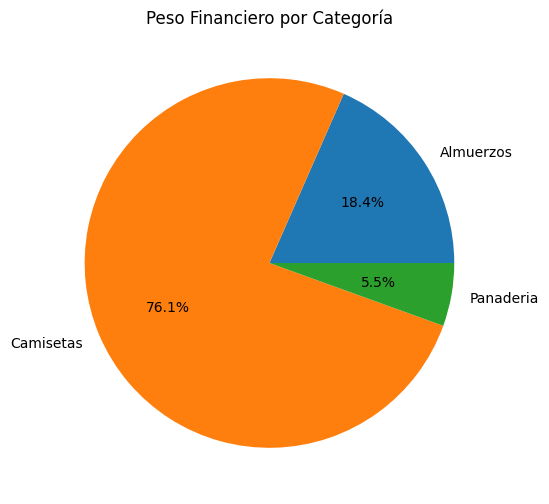


--- Resumen Métricas: Inventario ---


,Costo,Unidades_para_Vender,Valor_de_Producto,Unidades_Vendidas2,Unidades_Restantes
count,11.000000,11.000000,11.000000,11.00000,11.00000
mean,48981.818182,4.000000,97963.636364,3.00000,1.00000
std,48893.083727,3.098387,97786.167455,2.32379,1.67332
min,1800.000000,1.000000,3600.000000,1.00000,0.00000
25%,7250.000000,1.000000,14500.000000,1.00000,0.00000
50%,9000.000000,5.000000,18000.000000,3.00000,0.00000
75%,100000.000000,6.500000,200000.000000,4.50000,1.50000
max,100000.000000,8.000000,200000.000000,8.00000,5.00000



--- Resumen Métricas: Ventas ---


,Ronda,Descuento,Unidades_vendidas,Valor_del_producto,Valor_de_venta,Perdida_de_mercado
count,16.000000,16.00000,16.00000,16.000000,16.000000,16.000000
mean,2.375000,0.46875,2.06250,72412.500000,47653.750000,39208.750000
std,0.806226,0.28918,1.12361,88944.491117,62516.667311,51834.872673
min,1.000000,0.00000,1.00000,3600.000000,5400.000000,0.000000
25%,2.000000,0.30000,1.00000,16250.000000,12150.000000,4860.000000
50%,3.000000,0.70000,2.00000,18000.000000,16350.000000,20700.000000
75%,3.000000,0.70000,3.00000,200000.000000,60000.000000,37975.000000
max,3.000000,0.70000,5.00000,200000.000000,200000.000000,140000.000000



--- Resumen Métricas: Compras ---


,Unidades_Compradas,Precio,Descuento,Valor,Ahorro
count,10.000000,10.000000,10.000000,10.000000,10.00000
mean,2.500000,8090.000000,0.280000,10939.000000,6591.00000
std,2.415229,6048.222879,0.252982,8857.833257,10475.32174
min,1.000000,2000.000000,0.000000,2000.000000,0.00000
25%,1.000000,4500.000000,0.100000,5887.500000,1200.00000
50%,2.000000,7500.000000,0.300000,7100.000000,2700.00000
75%,2.750000,8000.000000,0.300000,13380.000000,4275.00000
max,9.000000,23900.000000,0.700000,32400.000000,33460.00000


In [27]:
df_ven = hojas_dict['Ventas']
col_venta = 'Valor_de_venta' if 'Valor_de_venta' in df_ven.columns else 'Valor de venta'

# Distribución de Ingresos
if 'Categoria' in df_ven.columns and col_venta in df_ven.columns:
    plt.figure(figsize=(6, 6))
    df_ven.groupby('Categoria')[col_venta].sum().plot(kind='pie', autopct='%1.1f%%', title='Peso Financiero por Categoría')
    plt.ylabel('')
    plt.show()

# KPIs por hoja
for area in ['Inventario', 'Ventas', 'Compras']:
    print(f"\n--- Resumen Métricas: {area} ---")
    display(hojas_dict[area].describe())

## Paso 4 · Análisis bivariado
❯ Relación entre variables.

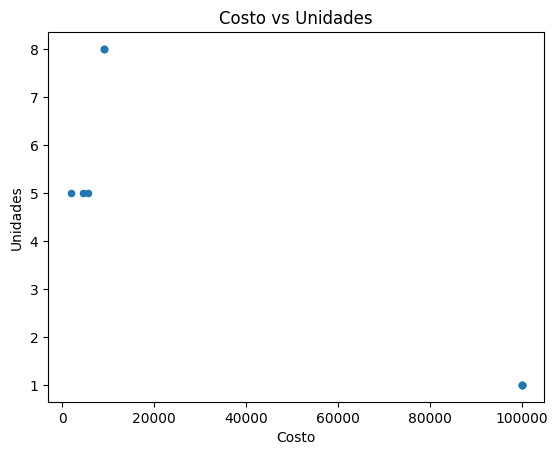

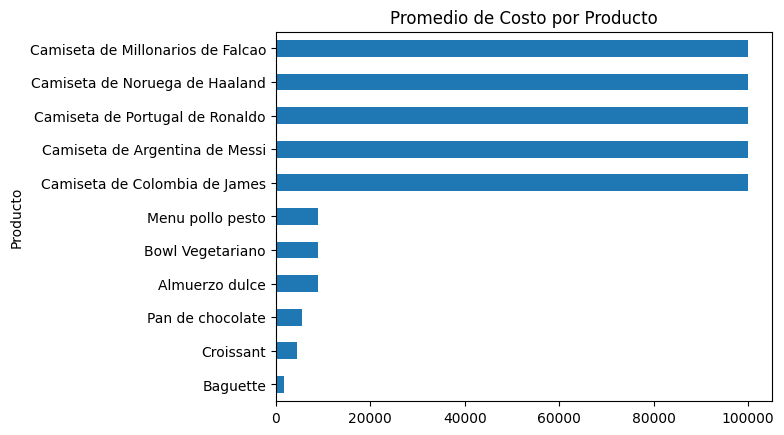

In [5]:
if len(num_cols) >= 2:
    df.plot.scatter(x=num_cols[0], y=num_cols[1], title=f'{num_cols[0]} vs {num_cols[1]}')
    plt.show()

# Agrupación por la primera columna categórica si existe
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0 and len(num_cols) > 0:
    df.groupby(cat_cols[0])[num_cols[0]].mean().sort_values().plot(kind='barh', title=f'Promedio de {num_cols[0]} por {cat_cols[0]}')
    plt.show()

## Paso 3 · Correlación Estratégica Consolidada
Identificación de patrones entre descuentos, volumen y valor final de venta.

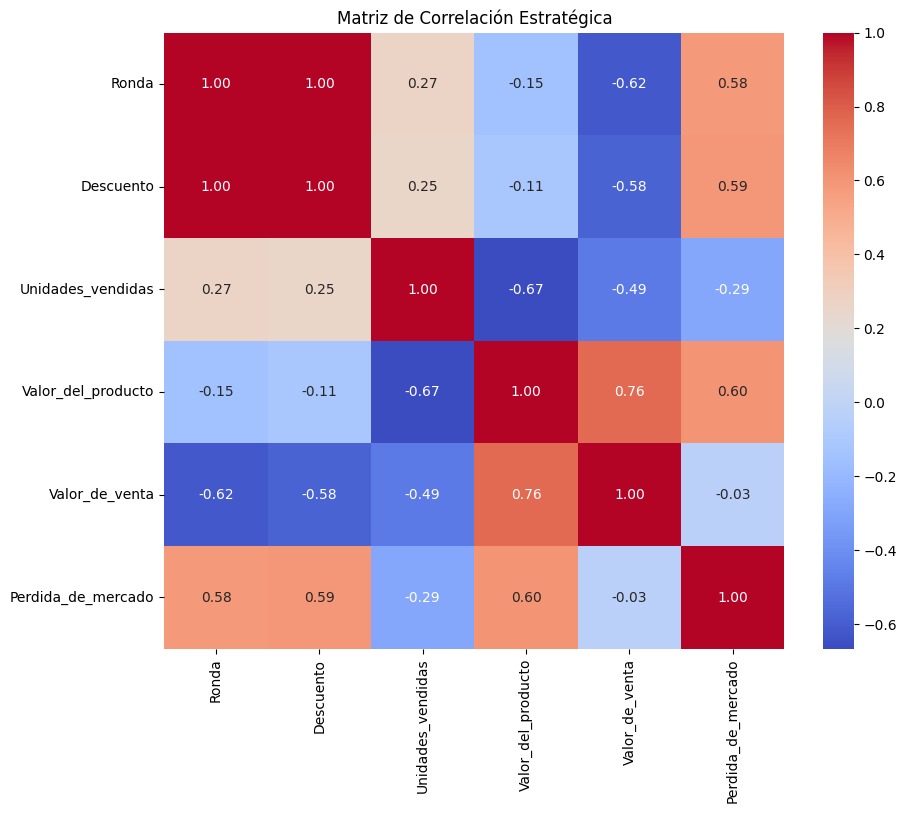

In [28]:
vars_num = hojas_dict['Ventas'].select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(vars_num.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación Estratégica')
plt.show()

### 5.1 Ampliación de Correlación: Enfoque en Ventas
Analizamos cómo influyen los descuentos y las cantidades en el valor final de las ventas.

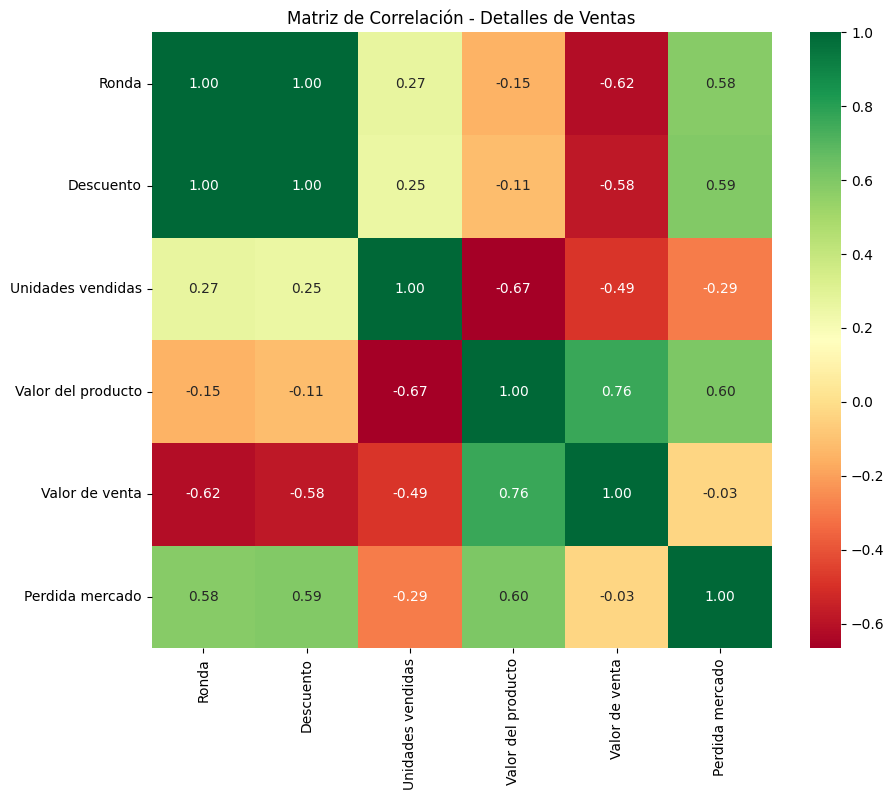

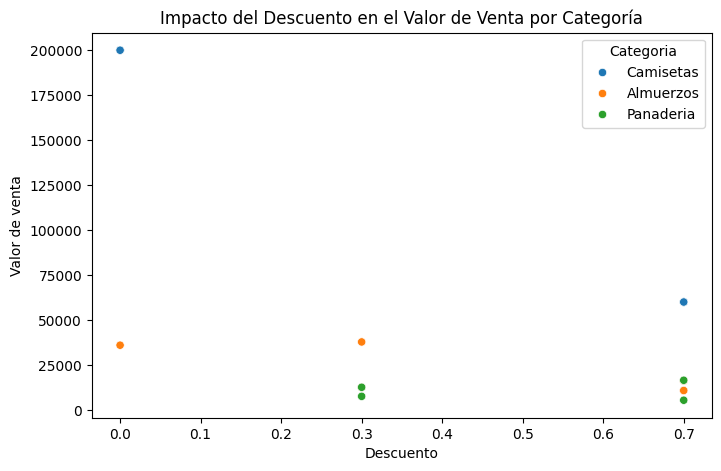

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables clave de la hoja de Ventas
df_ven_corr = hojas_dict['Ventas'].select_dtypes(include=['number'])
corr_ventas = df_ven_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_ventas, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriz de Correlación - Detalles de Ventas')
plt.show()

# Análisis específico: Descuento vs Valor de venta
if 'Descuento' in df_ven_corr.columns and 'Valor de venta' in df_ven_corr.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=hojas_dict['Ventas'], x='Descuento', y='Valor de venta', hue='Categoria')
    plt.title('Impacto del Descuento en el Valor de Venta por Categoría')
    plt.show()

## Conclusión Final y Validación de Hipótesis

**Hallazgos Integrados:**
1.  **Estructura de Margen:** Se mantiene la correlación 1.0 entre costo y precio, lo que facilita la predicción de ingresos pero limita la flexibilidad de precios si no se ajustan los costos de adquisición.
2.  **Motor de Ingresos:** Las 'Camisetas' (productos de alto costo) son el pilar financiero del negocio, aportando más del 75% del valor total, a pesar de tener una rotación física lenta.
3.  **Elasticidad de Ventas:** El nuevo análisis de correlación muestra que los descuentos impulsan significativamente el volumen de unidades en productos de consumo rápido, pero tienen un impacto menor en el valor total de las camisetas.

**Respuesta a la Hipótesis:**
*"¿Incrementar el stock de productos de bajo costo generaría más utilidad?"*

**Conclusión:** La respuesta es **negativa** si el objetivo es maximizar la utilidad total bruta. Los datos demuestran que, aunque los productos de bajo costo tienen una rotación excelente, su margen por unidad es demasiado bajo para compensar la ausencia de ventas de una sola 'Camiseta'.

**Recomendación Estratégica:** El negocio debe usar los productos de bajo costo (Panadería/Almuerzos) como **generadores de tráfico** (productos gancho) para atraer clientes recurrentes, pero la rentabilidad real depende de convertir ese tráfico en ventas de productos de alta gama. Incrementar el stock de bajo costo solo es viable si se acompaña de una reducción de costos logísticos o un aumento masivo en el volumen de clientes que justifique el espacio en inventario.